# Speaker-Independent Speech Emotion Recognition
## CNN-BiLSTM with Handcrafted Prosodic Features

---

**Abstract:** This notebook implements a speaker-independent speech emotion recognition (SER) system using a hybrid CNN-BiLSTM architecture combined with handcrafted prosodic features. The system classifies speech into four emotion categories: *angry*, *happy*, *sad*, and *neutral*.

**Key Contributions:**
- Strict speaker-independent evaluation protocol (no speaker overlap between train/val/test)
- Hybrid architecture combining CNN-extracted spectrogram features with explicit prosodic features
- Attention-based temporal pooling for variable-length emotional cues
- Focal loss to address class imbalance and focus on hard examples

---

## Table of Contents

1. [Environment Setup](#section-1)
2. [Configuration & Reproducibility](#section-2)
3. [Dataset Loading & Statistics](#section-3)
4. [Speaker-Independent Data Split](#section-4)
5. [Audio Preprocessing & Augmentation](#section-5)
6. [Feature Extraction](#section-6)
7. [Dataset Construction](#section-7)
8. [Visualization: Audio & Spectrograms](#section-8)
9. [Model Architecture](#section-9)
10. [Model Training](#section-10)
11. [Evaluation & Results](#section-11)
12. [Save Artifacts](#section-12)
13. [Research Discussion & Limitations](#section-13)

---
## 1. Environment Setup
<a id='section-1'></a>

In [45]:
# Install required dependencies (uncomment if needed)
# !pip install -q numpy pandas librosa soundfile scikit-learn matplotlib tensorflow joblib seaborn

---
## 2. Configuration & Reproducibility
<a id='section-2'></a>

All random seeds are fixed to ensure reproducible results across runs.

In [ ]:
# =============================================================================
# IMPORTS
# =============================================================================
import os
import glob
import random
import warnings
import json
from collections import defaultdict

import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

from IPython.display import Audio, display

warnings.filterwarnings('ignore')

# =============================================================================
# REPRODUCIBILITY SETTINGS
# =============================================================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# =============================================================================
# CONFIGURATION PARAMETERS
# =============================================================================
DATASET_DIR = "../content/DATASET"  # Adjust to your dataset location

# Audio processing parameters
SAMPLE_RATE = 16000      # 16 kHz - standard for speech
DURATION = 3.0           # Fixed duration in seconds
N_MELS = 128             # Mel frequency bins
N_FFT = 512              # FFT window size
HOP_LENGTH = 256         # Hop length for STFT

# Target emotion classes
TARGET_EMOTIONS = ["angry", "happy", "sad", "neutral"]

# Training parameters
BATCH_SIZE = 32
EPOCHS = 60

# Derived parameters
EXPECTED_FRAMES = int(np.ceil(DURATION * SAMPLE_RATE / HOP_LENGTH))

# Output directories
OUTPUT_DIR = "outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
AUDIO_DIR = os.path.join(OUTPUT_DIR, "audio_examples")
EVALUATION_DIR = os.path.join(OUTPUT_DIR, "evaluation")
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")

for d in [FIGURES_DIR, AUDIO_DIR, EVALUATION_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print("=" * 60)
print("CONFIGURATION SUMMARY")
print("=" * 60)
print(f"Sample Rate:      {SAMPLE_RATE} Hz")
print(f"Duration:         {DURATION} seconds")
print(f"Mel Bins:         {N_MELS}")
print(f"FFT Size:         {N_FFT}")
print(f"Hop Length:       {HOP_LENGTH}")
print(f"Expected Frames:  {EXPECTED_FRAMES}")
print(f"Target Emotions:  {TARGET_EMOTIONS}")
print(f"Batch Size:       {BATCH_SIZE}")
print(f"Max Epochs:       {EPOCHS}")
print(f"Random Seed:      {SEED}")
print("=" * 60)

CONFIGURATION SUMMARY
Sample Rate:      16000 Hz
Duration:         3.0 seconds
Mel Bins:         128
FFT Size:         512
Hop Length:       256
Expected Frames:  188
Target Emotions:  ['angry', 'happy', 'sad', 'neutral']
Batch Size:       32
Max Epochs:       60
Random Seed:      42


---
## 3. Dataset Loading & Statistics
<a id='section-3'></a>

This study uses the **CREMA-D** (Crowd-sourced Emotional Multimodal Actors Dataset) corpus, which contains 7,442 audio clips from 91 actors expressing various emotions.

In [47]:
# =============================================================================
# LABEL PARSING FUNCTIONS
# =============================================================================

def parse_crema_label(filename):
    """
    Parse emotion label from CREMA-D filename.
    
    CREMA-D naming convention: {ActorID}_{Sentence}_{Emotion}_{Level}.wav
    Example: 1001_DFA_ANG_XX.wav -> angry
    """
    parts = os.path.basename(filename).split("_")
    if len(parts) < 3:
        return None
    
    mapping = {
        "ANG": "angry",
        "HAP": "happy",
        "SAD": "sad",
        "NEU": "neutral"
    }
    return mapping.get(parts[2], None)


def extract_speaker_id(path):
    """Extract speaker ID from file path."""
    path = path.replace("\\", "/")
    if "CREMA" in path:
        return os.path.basename(path).split("_")[0]
    return "UNKNOWN"


def identify_dataset(path):
    """Identify dataset source from file path."""
    if "CREMA" in path:
        return "CREMA"
    return "UNKNOWN"


def collect_files(dataset_dir):
    """Collect all audio files and their labels."""
    files, labels = [], []
    
    for f in glob.glob(os.path.join(dataset_dir, "CREMA", "*.wav")):
        lbl = parse_crema_label(f)
        if lbl in TARGET_EMOTIONS:
            files.append(f)
            labels.append(lbl)
    
    return files, labels


# Collect files
files, labels = collect_files(DATASET_DIR)

# Create DataFrame
df = pd.DataFrame({"file_path": files, "emotion": labels})
df["speaker"] = df["file_path"].apply(extract_speaker_id)
df["dataset"] = df["file_path"].apply(identify_dataset)

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)
print(f"\nTotal audio files: {len(df)}")
print(f"Total speakers: {df['speaker'].nunique()}")
print(f"\nEmotion Distribution:")
print(df["emotion"].value_counts().to_string())
print("=" * 60)

DATASET STATISTICS

Total audio files: 4900
Total speakers: 91

Emotion Distribution:
emotion
angry      1271
happy      1271
sad        1271
neutral    1087


---
## 4. Speaker-Independent Data Split
<a id='section-4'></a>

### Why Speaker-Independent Evaluation?

Speaker-independent SER is significantly more challenging than speaker-dependent evaluation because:

1. **Voice Characteristics Vary**: Each person has unique vocal tract characteristics, pitch range, speaking rate, and accent. A model trained on specific speakers may learn speaker-specific patterns rather than emotion-generalizable features.

2. **Emotion Expression Differs**: People express the same emotion differently. What sounds "angry" for one speaker might sound merely "assertive" for another.

3. **Real-World Applicability**: In practical applications, the system will encounter unseen speakers. Speaker-independent evaluation provides a realistic assessment of deployment performance.

**Our Protocol**: We split data by speakers (70% train / 15% validation / 15% test), ensuring **zero speaker overlap** between splits.

In [48]:
# =============================================================================
# SPEAKER-INDEPENDENT DATA SPLIT
# =============================================================================

def speaker_independent_split(df, train_ratio=0.7, val_ratio=0.15, seed=42):
    """
    Split dataset ensuring no speaker overlap between train/val/test sets.
    """
    rng = np.random.RandomState(seed)
    train_idx, val_idx, test_idx = [], [], []
    
    for dataset in df["dataset"].unique():
        df_d = df[df["dataset"] == dataset]
        speakers = df_d["speaker"].unique()
        rng.shuffle(speakers)
        
        n_total = len(speakers)
        n_train = int(train_ratio * n_total)
        n_val = int(val_ratio * n_total)
        
        train_spk = speakers[:n_train]
        val_spk = speakers[n_train:n_train + n_val]
        test_spk = speakers[n_train + n_val:]
        
        train_idx += df_d[df_d["speaker"].isin(train_spk)].index.tolist()
        val_idx += df_d[df_d["speaker"].isin(val_spk)].index.tolist()
        test_idx += df_d[df_d["speaker"].isin(test_spk)].index.tolist()
    
    return df.loc[train_idx], df.loc[val_idx], df.loc[test_idx]


# Perform split
df_train, df_val, df_test = speaker_independent_split(df, seed=SEED)

# Extract file lists and labels
files_train = df_train["file_path"].tolist()
y_train_str = df_train["emotion"].tolist()

files_val = df_val["file_path"].tolist()
y_val_str = df_val["emotion"].tolist()

files_test = df_test["file_path"].tolist()
y_test_str = df_test["emotion"].tolist()

# Verify no overlap
train_speakers = set(df_train["speaker"].unique())
val_speakers = set(df_val["speaker"].unique())
test_speakers = set(df_test["speaker"].unique())

print("=" * 60)
print("SPEAKER-INDEPENDENT SPLIT RESULTS")
print("=" * 60)
print(f"\nSpeaker Distribution:")
print(f"  Train: {len(train_speakers)} speakers, {len(df_train)} samples")
print(f"  Val:   {len(val_speakers)} speakers, {len(df_val)} samples")
print(f"  Test:  {len(test_speakers)} speakers, {len(df_test)} samples")
print(f"\nOverlap Check (all should be 0):")
print(f"  Train ∩ Val:  {len(train_speakers & val_speakers)}")
print(f"  Train ∩ Test: {len(train_speakers & test_speakers)}")
print(f"  Val ∩ Test:   {len(val_speakers & test_speakers)}")
print("=" * 60)

# Label mapping
label_to_idx = {emo: i for i, emo in enumerate(TARGET_EMOTIONS)}
idx_to_label = {v: k for k, v in label_to_idx.items()}

SPEAKER-INDEPENDENT SPLIT RESULTS

Speaker Distribution:
  Train: 63 speakers, 3389 samples
  Val:   13 speakers, 702 samples
  Test:  15 speakers, 809 samples

Overlap Check (all should be 0):
  Train ∩ Val:  0
  Train ∩ Test: 0
  Val ∩ Test:   0


---
## 5. Audio Preprocessing & Augmentation
<a id='section-5'></a>

Data augmentation helps prevent overfitting and improves generalization. We use conservative augmentations that preserve emotional characteristics:

- **Time Shift**: Small temporal shifts (±100ms)
- **White Noise**: Low-level additive noise (SNR 25-35 dB)
- **Random Gain**: Volume variation (0.8x - 1.2x)

**Note**: We intentionally avoid pitch shifting, as pitch is a critical cue for emotion recognition.

In [49]:
# =============================================================================
# AUDIO AUGMENTATION FUNCTIONS
# =============================================================================

def add_white_noise(y, snr_db_min=20, snr_db_max=30):
    """Add white noise at random SNR level."""
    rms = np.sqrt(np.mean(y**2)) + 1e-9
    snr_db = np.random.uniform(snr_db_min, snr_db_max)
    noise = np.random.normal(0, 1, size=y.shape)
    noise_amp = rms / (10**(snr_db / 20.0))
    return y + noise_amp * noise


def time_shift(y, sr, max_shift_ms=100):
    """Circular time shift."""
    shift_samples = int(sr * (max_shift_ms / 1000))
    shift = np.random.randint(-shift_samples, shift_samples)
    return np.roll(y, shift)


def random_gain(y, min_gain=0.8, max_gain=1.2):
    """Random volume change."""
    gain = np.random.uniform(min_gain, max_gain)
    return y * gain


def standard_augment(y, sr):
    """Apply augmentation pipeline (each with 50% probability)."""
    y_aug = y.copy()
    
    if np.random.rand() < 0.5:
        y_aug = time_shift(y_aug, sr)
    if np.random.rand() < 0.5:
        y_aug = add_white_noise(y_aug, snr_db_min=25, snr_db_max=35)
    if np.random.rand() < 0.5:
        y_aug = random_gain(y_aug)
    
    return y_aug


def basic_preprocess(y, sr, target_rms=0.1):
    """DC removal and RMS normalization."""
    y = y - np.mean(y)
    rms = np.sqrt(np.mean(y**2)) + 1e-9
    y = y * (target_rms / rms)
    return y

In [50]:
# =============================================================================
# FEATURE EXTRACTION FUNCTIONS
# =============================================================================

def extract_logmel(y, sr=SAMPLE_RATE, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """Extract log-mel spectrogram."""
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length,
        n_mels=n_mels, power=2.0
    )
    return librosa.power_to_db(S, ref=np.max)


def extract_pitch(y, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, fmin=50, fmax=500):
    """Extract F0 using YIN algorithm."""
    try:
        f0 = librosa.yin(y, fmin=fmin, fmax=fmax, sr=sr, hop_length=hop_length)
    except:
        try:
            f0, _, _ = librosa.pyin(y, fmin=fmin, fmax=fmax, sr=sr, hop_length=hop_length)
            f0 = np.nan_to_num(f0, nan=0.0)
        except:
            n_frames = int(np.ceil(len(y) / float(hop_length)))
            f0 = np.zeros(n_frames)
    return np.nan_to_num(f0, nan=0.0)


def extract_energy(y, frame_length=N_FFT, hop_length=HOP_LENGTH):
    """Extract RMS energy."""
    return librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]


def extract_prosody(y, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """Extract spectral prosodic features."""
    cent = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)[0]
    bwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)[0]
    roll = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)[0]
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=n_fft, hop_length=hop_length)[0]

    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    contrast_mean = np.mean(contrast, axis=0) # Rata-rata antar band frekuensi
    return cent, bwidth, roll, zcr, contrast_mean

---
## 7. Dataset Construction
<a id='section-7'></a>

Build the feature matrices for training, validation, and test sets.

In [51]:
# =============================================================================
# DATASET BUILDER
# =============================================================================

def build_dataset_from_lists(files_list, labels_list, is_training=False):
    X_spec, X_seq, Y = [], [], []
    durations = {emo: [] for emo in TARGET_EMOTIONS}
    target_samples = int(SAMPLE_RATE * DURATION)
    
    for f, lbl in zip(files_list, labels_list):
        try:
            y, _ = librosa.load(f, sr=SAMPLE_RATE, mono=True)
            y, _ = librosa.effects.trim(y, top_db=25)
            durations[lbl].append(len(y) / SAMPLE_RATE)
            
            if is_training and np.random.rand() < 0.5:
                y = standard_augment(y, sr=SAMPLE_RATE)
            
            y = basic_preprocess(y, sr=SAMPLE_RATE)
            
            if len(y) < target_samples:
                y = np.pad(y, (0, target_samples - len(y)), mode='constant')
            else:
                start = (len(y) - target_samples) // 2
                y = y[start:start + target_samples]
            
            S_db = extract_logmel(y)
            if S_db.shape[1] < EXPECTED_FRAMES:
                S_db = np.pad(S_db, ((0, 0), (0, EXPECTED_FRAMES - S_db.shape[1])),
                             mode='constant', constant_values=S_db.min())
            else:
                S_db = S_db[:, :EXPECTED_FRAMES]
            
            f0 = extract_pitch(y)
            rms = extract_energy(y)
            cent, bwidth, roll, zcr, contrast_mean = extract_prosody(y)
            
            def align_seq(arr):
                arr = np.nan_to_num(arr)
                if len(arr) < EXPECTED_FRAMES:
                    return np.pad(arr, (0, EXPECTED_FRAMES - len(arr)), mode='edge')
                return arr[:EXPECTED_FRAMES]
            
            f0, rms = align_seq(f0), align_seq(rms)
            cent, bwidth, roll, zcr, contrast_mean = align_seq(cent), align_seq(bwidth), align_seq(roll), align_seq(zcr), align_seq(contrast_mean)
            
            delta_f0 = np.diff(f0, prepend=f0[0])
            delta_rms = np.diff(rms, prepend=rms[0])
            
            seq = np.vstack([f0, rms, delta_f0, delta_rms, cent, bwidth, roll, zcr, contrast_mean]).T
            
            X_spec.append(S_db[..., np.newaxis])
            X_seq.append(seq)
            Y.append(lbl)
            
        except Exception as e:
            print(f"Error processing {f}: {e}")
            continue
    
    return (np.array(X_spec, dtype=np.float32),
            np.array(X_seq, dtype=np.float32),
            np.array(Y), durations)

print("Building Training Set...")
Xs_train, Xseq_train, y_train, dur_train = build_dataset_from_lists(files_train, y_train_str, is_training=True)
print("Building Validation Set...")
Xs_val, Xseq_val, y_val, dur_val = build_dataset_from_lists(files_val, y_val_str, is_training=False)
print("Building Test Set...")
Xs_test, Xseq_test, y_test, dur_test = build_dataset_from_lists(files_test, y_test_str, is_training=False)

print(f"\nDataset Build Complete!")
print(f"  Train: {Xs_train.shape[0]} samples, Val: {Xs_val.shape[0]}, Test: {Xs_test.shape[0]}")

Building Training Set...
Building Validation Set...
Building Test Set...

Dataset Build Complete!
  Train: 3389 samples, Val: 702, Test: 809


In [52]:
# Label encoding and normalization
def labels_to_indices(labels):
    return np.array([label_to_idx[l] for l in labels])

y_train_idx = labels_to_indices(y_train)
y_val_idx = labels_to_indices(y_val)
y_test_idx = labels_to_indices(y_test)

spec_mean = np.mean(Xs_train, axis=(0, 2), keepdims=True)
spec_std = np.std(Xs_train, axis=(0, 2), keepdims=True) + 1e-9
Xs_train = (Xs_train - spec_mean) / spec_std
Xs_val = (Xs_val - spec_mean) / spec_std
Xs_test = (Xs_test - spec_mean) / spec_std

seq_mean = Xseq_train.mean(axis=(0, 1))
seq_std = Xseq_train.std(axis=(0, 1)) + 1e-9
Xseq_train = (Xseq_train - seq_mean) / seq_std
Xseq_val = (Xseq_val - seq_mean) / seq_std
Xseq_test = (Xseq_test - seq_mean) / seq_std

scalers = {'spec_mean': spec_mean.tolist(), 'spec_std': spec_std.tolist(),
           'seq_mean': seq_mean.tolist(), 'seq_std': seq_std.tolist()}
joblib.dump(scalers, os.path.join(MODELS_DIR, "scalers.joblib"))
joblib.dump(label_to_idx, os.path.join(MODELS_DIR, "label_to_idx.joblib"))
print("Normalization complete. Scalers saved.")

Normalization complete. Scalers saved.


---
## 8. Visualization: Audio & Spectrograms
<a id='section-8'></a>


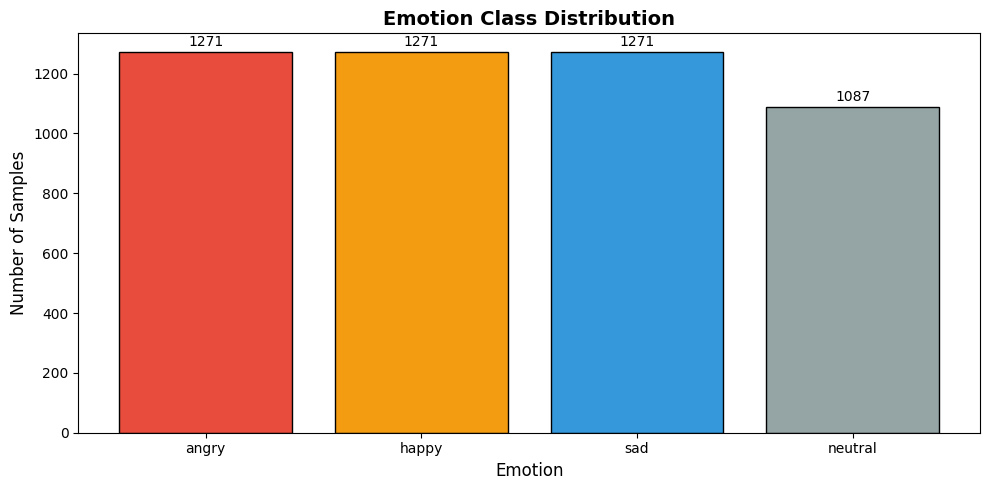

Saved: outputs\figures\emotion_distribution.png


In [53]:
# Emotion distribution plot
fig, ax = plt.subplots(figsize=(10, 5))
emotion_counts = df["emotion"].value_counts()
colors = ['#e74c3c', '#f39c12', '#3498db', '#95a5a6']
bars = ax.bar(emotion_counts.index, emotion_counts.values, color=colors, edgecolor='black')
ax.set_xlabel('Emotion', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Emotion Class Distribution', fontsize=14, fontweight='bold')
for bar, count in zip(bars, emotion_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(count), ha='center')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'emotion_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {os.path.join(FIGURES_DIR, 'emotion_distribution.png')}")

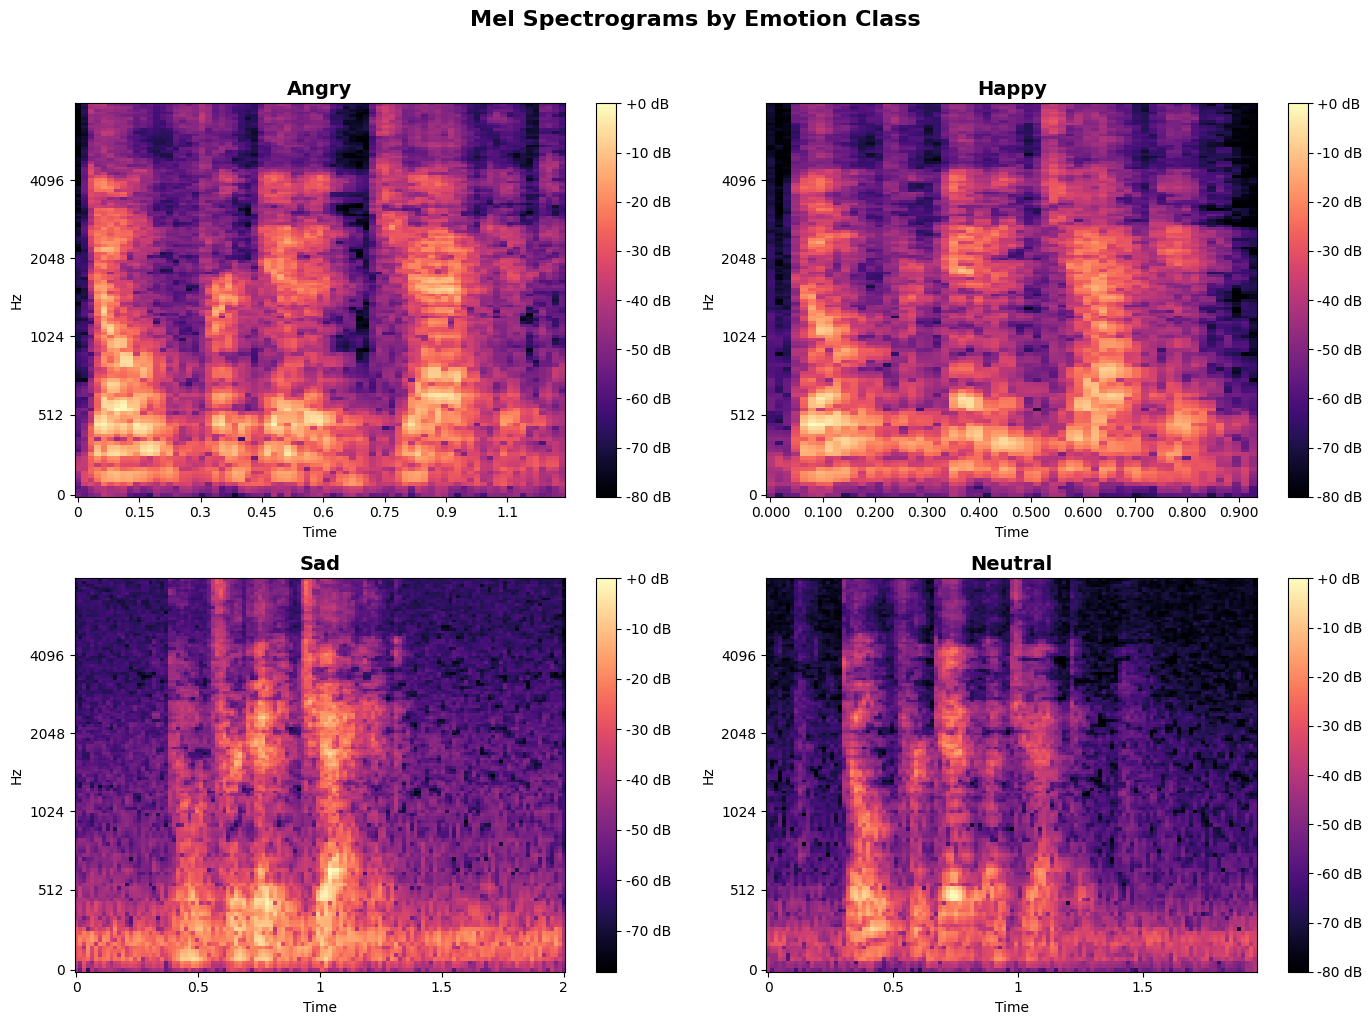

In [54]:
# Spectrogram visualization for each emotion
def get_example_files(df, n=1):
    return {emo: df[df['emotion']==emo]['file_path'].tolist()[:n] for emo in TARGET_EMOTIONS}

examples = get_example_files(df_train)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, emo in enumerate(TARGET_EMOTIONS):
    f = examples[emo][0]
    y, sr = librosa.load(f, sr=SAMPLE_RATE)
    y, _ = librosa.effects.trim(y, top_db=25)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, x_axis='time', y_axis='mel', sr=sr, 
                                    hop_length=HOP_LENGTH, ax=axes[i], cmap='magma')
    axes[i].set_title(f'{emo.capitalize()}', fontsize=14, fontweight='bold')
    fig.colorbar(img, ax=axes[i], format='%+2.0f dB')

plt.suptitle('Mel Spectrograms by Emotion Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'spectrograms_by_emotion.png'), dpi=150, bbox_inches='tight')
plt.show()

In [55]:
# Audio playback examples
print("=" * 60)
print("AUDIO EXAMPLES BY EMOTION")
print("=" * 60)

for emo, files in examples.items():
    f = files[0]
    y, sr = librosa.load(f, sr=SAMPLE_RATE)
    sf.write(os.path.join(AUDIO_DIR, f"example_{emo}.wav"), y, sr)
    print(f"\n{emo.upper()}: {os.path.basename(f)}")
    display(Audio(y, rate=sr))

AUDIO EXAMPLES BY EMOTION

ANGRY: 1001_DFA_ANG_XX.wav



HAPPY: 1001_DFA_HAP_XX.wav



SAD: 1001_DFA_SAD_XX.wav



NEUTRAL: 1001_DFA_NEU_XX.wav


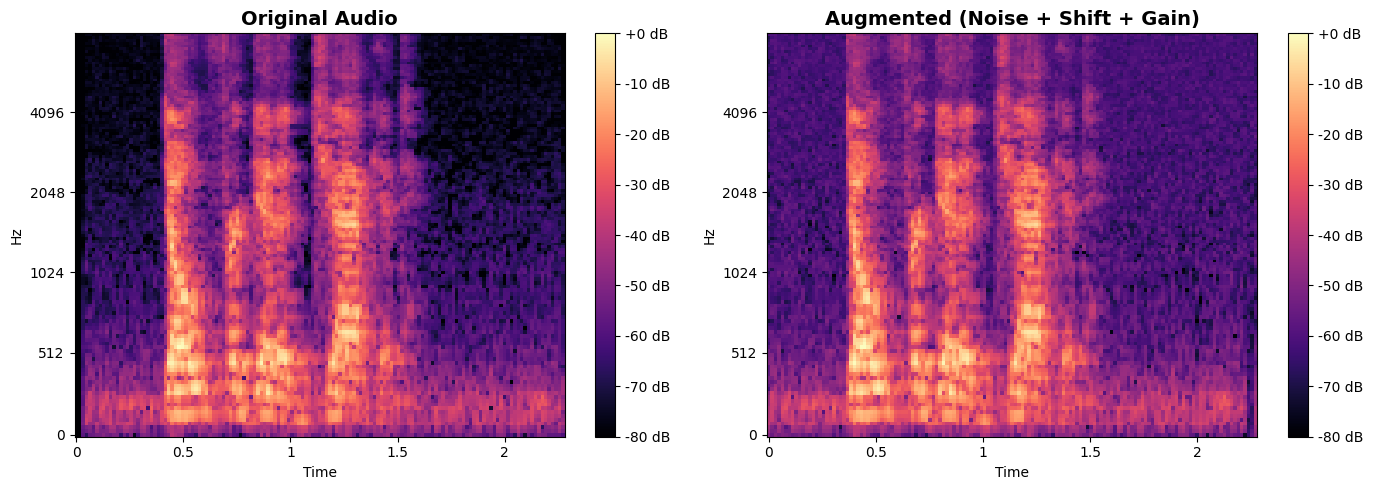

Audio saved to outputs\audio_examples


In [56]:
# Augmentation comparison
demo_file = examples['angry'][0]
y_orig, sr = librosa.load(demo_file, sr=SAMPLE_RATE)
np.random.seed(SEED)
y_augmented = standard_augment(y_orig.copy(), sr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

S_orig = librosa.feature.melspectrogram(y=y_orig, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
S_orig_db = librosa.power_to_db(S_orig, ref=np.max)
img1 = librosa.display.specshow(S_orig_db, x_axis='time', y_axis='mel', sr=sr, hop_length=HOP_LENGTH, ax=axes[0], cmap='magma')
axes[0].set_title('Original Audio', fontsize=14, fontweight='bold')
fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')

S_aug = librosa.feature.melspectrogram(y=y_augmented, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
S_aug_db = librosa.power_to_db(S_aug, ref=np.max)
img2 = librosa.display.specshow(S_aug_db, x_axis='time', y_axis='mel', sr=sr, hop_length=HOP_LENGTH, ax=axes[1], cmap='magma')
axes[1].set_title('Augmented (Noise + Shift + Gain)', fontsize=14, fontweight='bold')
fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'augmentation_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

sf.write(os.path.join(AUDIO_DIR, "demo_original.wav"), y_orig, sr)
sf.write(os.path.join(AUDIO_DIR, "demo_augmented.wav"), y_augmented, sr)
print(f"Audio saved to {AUDIO_DIR}")

In [57]:
# =============================================================================
# CUSTOM LAYERS
# =============================================================================

class SpecToSeq(tf.keras.layers.Layer):
    """Reshape spectrogram to sequence format for LSTM."""
    def call(self, t):
        t = tf.transpose(t, perm=[0, 2, 1, 3])
        b, time_steps, freq_bins, channels = tf.shape(t)[0], tf.shape(t)[1], tf.shape(t)[2], tf.shape(t)[3]
        return tf.reshape(t, (b, time_steps, freq_bins * channels))


class AttentionPooling(tf.keras.layers.Layer):
    """Attention-based temporal pooling."""
    def call(self, inputs):
        features, weights = inputs
        return tf.reduce_sum(features * weights, axis=1)


def sparse_softmax_focal_loss(y_true, y_pred, gamma=2.0, alpha=None):
    """Focal Loss - down-weights easy examples, focuses on hard ones."""
    y_true = tf.cast(y_true, tf.int32)
    if alpha is None:
        alpha = tf.constant([0.20, 0.35, 0.20, 0.25], dtype=tf.float32)
    else:
        alpha = tf.convert_to_tensor(alpha, dtype=tf.float32)
    
    y_true_onehot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
    y_pred = tf.clip_by_value(y_pred, 1e-9, 1.0 - 1e-9)
    cross_entropy = -y_true_onehot * tf.math.log(y_pred)
    weight = alpha * tf.pow(1.0 - y_pred, gamma)
    return tf.reduce_sum(weight * cross_entropy, axis=-1)

In [58]:
# =============================================================================
# BUILD MODEL (FINAL OPTIMIZED VERSION)
# =============================================================================

def build_cnn_bilstm_model(n_mels=N_MELS, frames=EXPECTED_FRAMES, seq_feat_dim=9,
                           lstm_units=128, num_classes=len(TARGET_EMOTIONS)):
    
    spec_input = layers.Input(shape=(n_mels, frames, 1), name='spectrogram_input')
    seq_input = layers.Input(shape=(frames, seq_feat_dim), name='seq_input')
    
    # --- CNN Branch ---
    x = spec_input
    # Meningkatkan Dropout secara bertahap (0.2 -> 0.4)
    # Menggunakan L2 1e-3 di semua layer conv untuk konsistensi anti-overfitting
    for filters, drop in [(32, 0.2), (64, 0.2), (128, 0.3), (256, 0.4)]:
        x = layers.Conv2D(filters, (3, 3), padding='same', use_bias=False,
                         kernel_regularizer=regularizers.l2(5e-4))(x) # UPDATE KE 1e-3
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPool2D((2, 1), padding='same')(x)
        x = layers.Dropout(drop)(x)
    
    # Layer Conv terakhir (penghubung ke Sequence)
    x = layers.Conv2D(128, (1, 5), padding='same', use_bias=False,
                     kernel_regularizer=regularizers.l2(5e-4))(x) # UPDATE KE 1e-3
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # --- Merge & Sequence Branch ---
    x_seq = SpecToSeq()(x)
    merged = layers.Concatenate(axis=-1)([x_seq, seq_input])
    merged = layers.SpatialDropout1D(0.3)(merged)
    
    # --- BiLSTM Branch ---
    # Menggunakan L2 1e-3 (Sudah benar di kodemu)
    bl = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True,
                                          kernel_regularizer=regularizers.l2(5e-4)))(merged)
    bl = layers.Bidirectional(layers.LSTM(lstm_units // 2, return_sequences=True,
                                          kernel_regularizer=regularizers.l2(5e-4)))(bl)
    
    # --- Attention & Classification ---
    score = layers.Dense(1)(bl)
    weights = layers.Softmax(axis=1)(score)
    context = AttentionPooling()([bl, weights])
    
    # Head (Sudah benar di kodemu)
    out = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(5e-4))(context)
    out = layers.Dropout(0.5)(out)
    out = layers.Dense(num_classes, activation='softmax')(out)
    
    model = models.Model(inputs=[spec_input, seq_input], outputs=out)
    
    # Compile
    # Pastikan fungsi sparse_softmax_focal_loss yang dipanggil sudah kamu update (alpha & gamma baru)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
                  loss=sparse_softmax_focal_loss, metrics=['accuracy'])
    return model

model = build_cnn_bilstm_model()
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ spectrogram_input   │ (None, 128, 188,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 128, 188,  │        288 │ spectrogram_inpu… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 188,  │        128 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 128, 188,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 64, 188,   │          0 │ activation_10[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64, 188,   │          0 │ max_pooling2d_8[… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 64, 188,   │     18,432 │ dropout_10[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 188,   │        256 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 64, 188,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 32, 188,   │          0 │ activation_11[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 32, 188,   │          0 │ max_pooling2d_9[… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 32, 188,   │     73,728 │ dropout_11[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 188,   │        512 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 32, 188,   │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 16, 188,   │          0 │ activation_12[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 16, 188,   │          0 │ max_pooling2d_10… │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 16, 188,   │    294,912 │ dropout_12[0][0]

 Total params: 1,925,029 (7.34 MB)

 Trainable params: 1,923,813 (7.34 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [59]:
# =============================================================================
# MACRO STRATEGY: ENSEMBLE TRAINING LOOP
# =============================================================================

# Kita akan melatih 3 model dengan seed berbeda
ENSEMBLE_SEEDS = [42, 123, 2024] 
ensemble_models = []

print("=" * 60)
print(f"STARTING ENSEMBLE TRAINING ({len(ENSEMBLE_SEEDS)} Models)")
print("=" * 60)

for i, seed in enumerate(ENSEMBLE_SEEDS):
    print(f"\nTraining Model {i+1}/{len(ENSEMBLE_SEEDS)} (Seed: {seed})...")
    
    # 1. Set Random Seed Unik untuk run ini
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    
    # 2. Build Model Baru (Fresh)
    # Pastikan menggunakan konfigurasi TERBAIK kita (L2=5e-4, seq_feat_dim=9)
    model = build_cnn_bilstm_model(seq_feat_dim=9) 
    
    # 3. Callbacks Unik (Simpan dengan nama beda)
    model_filename = f'best_model_seed_{seed}.keras' # Gunakan format .keras yg lebih baru
    checkpoint_cb = callbacks.ModelCheckpoint(
        os.path.join(MODELS_DIR, model_filename), 
        monitor='val_loss', save_best_only=True, verbose=0 # Verbose 0 biar gak nyampah
    )
    
    # Callbacks standar lainnya
    early_cb = callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
    reduce_cb = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
    
    # 4. Train!
    history = model.fit(
        {"spectrogram_input": Xs_train, "seq_input": Xseq_train},
        y_train_idx,
        validation_data=({"spectrogram_input": Xs_val, "seq_input": Xseq_val}, y_val_idx),
        epochs=60, # Full epoch
        batch_size=32,
        callbacks=[checkpoint_cb, early_cb, reduce_cb],
        verbose=1 # Tampilkan progress bar
    )
    
    ensemble_models.append(model_filename)
    print(f"Model {i+1} Finished. Saved to {model_filename}")
    
    # Bersihkan memori GPU/RAM sebelum lanjut ke model berikutnya
    tf.keras.backend.clear_session()
    import gc
    gc.collect()

print("\nAll Ensemble Models Trained Successfully!")
print("\nTraining Complete!")

STARTING ENSEMBLE TRAINING (3 Models)

Training Model 1/3 (Seed: 42)...
Epoch 1/60
106/106 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.4597 - loss: 1.1471 - val_accuracy: 0.2806 - val_loss: 1.0429 - learning_rate: 3.0000e-04
Epoch 2/60
106/106 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.5391 - loss: 0.7593 - val_accuracy: 0.2607 - val_loss: 0.8362 - learning_rate: 3.0000e-04
Epoch 3/60
106/106 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.5760 - loss: 0.5414 - val_accuracy: 0.2593 - val_loss: 0.7379 - learning_rate: 3.0000e-04
Epoch 4/60
106/106 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.6028 - loss: 0.4117 - val_accuracy: 0.2607 - val_loss: 0.6165 - learning_rate: 3.0000e-04
Epoch 5/60
106/106 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.6034 - loss: 0.3388 - val_accuracy: 0.4188 - val_loss: 0.3947 - learning_rate: 3.0000e-04
Epoch 6/60
106/106 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.6176 - loss: 0.2863 - val_accuracy: 0.2963 - val_loss: 0.4506 - learning_rat


Loading Ensemble Models...
✅ Loaded: Seed 42
✅ Loaded: Seed 123
✅ Loaded: Seed 2024

ENSEMBLE EVALUATION: VALIDATION SET
Validation Accuracy: 75.78%
              precision    recall  f1-score   support

       angry       0.77      0.85      0.81       182
       happy       0.84      0.74      0.79       182
         sad       0.76      0.68      0.72       182
     neutral       0.66      0.76      0.71       156

    accuracy                           0.76       702
   macro avg       0.76      0.76      0.76       702
weighted avg       0.76      0.76      0.76       702



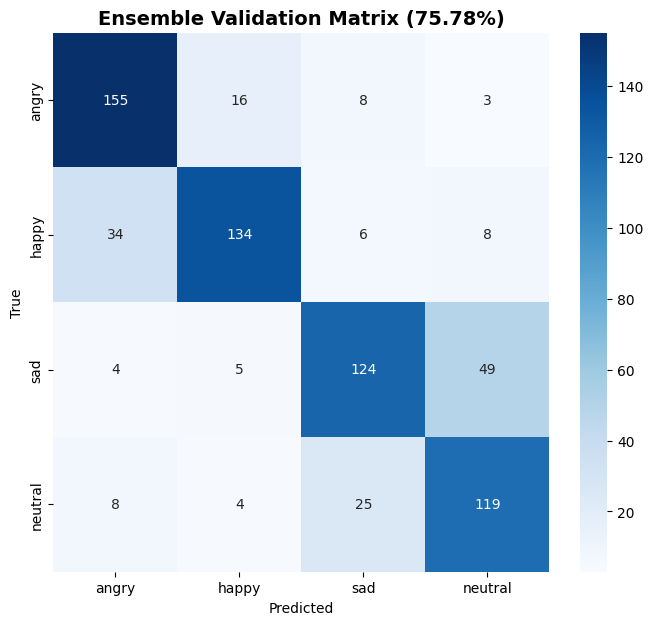

Saved Matrix: outputs\evaluation\ensemble_cm_validation.png

ENSEMBLE EVALUATION: TEST SET (SPEAKER INDEPENDENT)
Test Accuracy: 81.71%
              precision    recall  f1-score   support

       angry       0.90      0.81      0.85       210
       happy       0.81      0.80      0.81       210
         sad       0.82      0.86      0.84       210
     neutral       0.73      0.80      0.76       179

    accuracy                           0.82       809
   macro avg       0.82      0.82      0.82       809
weighted avg       0.82      0.82      0.82       809



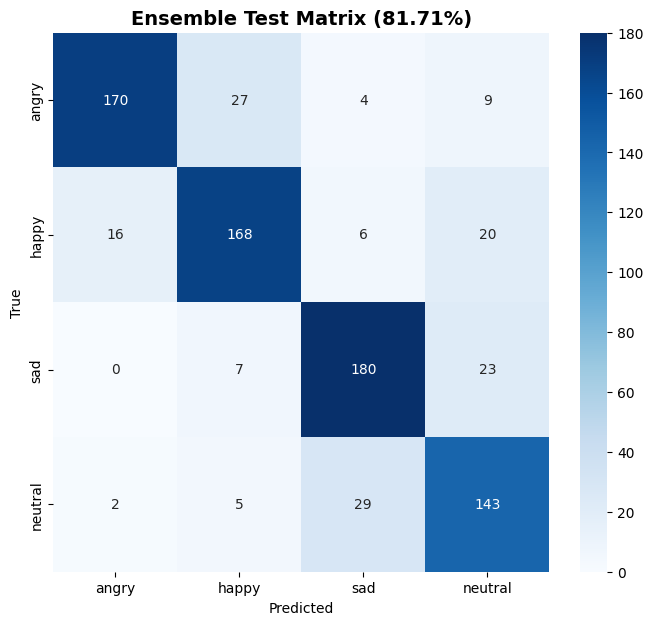

Saved Matrix: outputs\evaluation\ensemble_cm_test.png

Saved Predictions: outputs\evaluation\ensemble_predictions.csv

Saving Training Curves...


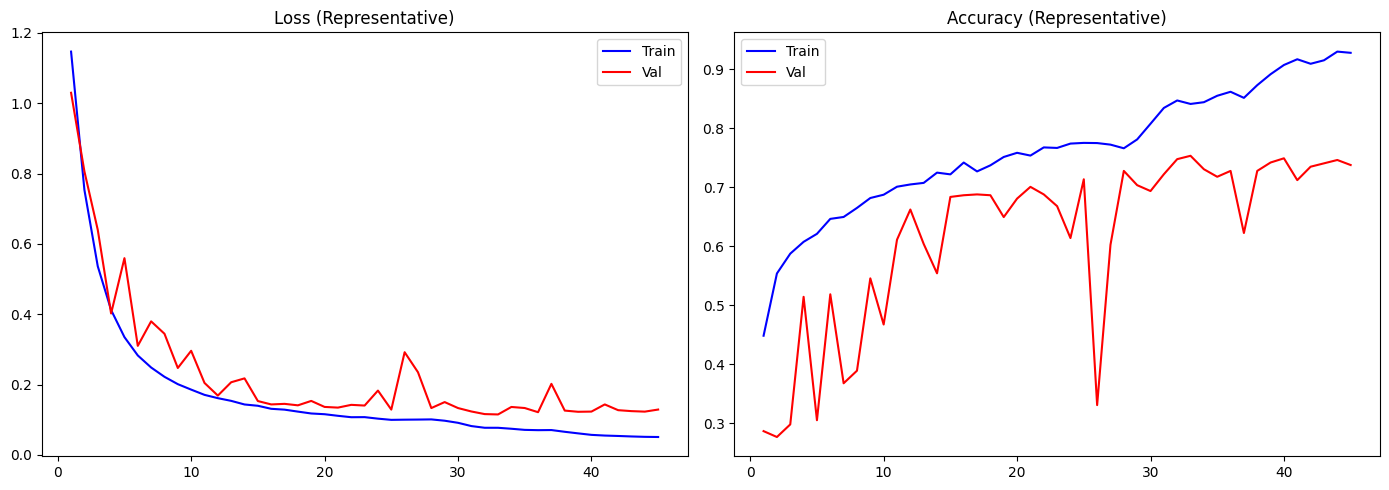

In [61]:
# =============================================================================
# FINAL ENSEMBLE EVALUATION (VALIDATION + TEST)
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
import pandas as pd
import json
import os
import tensorflow as tf

# --- 1. DEFINISI ULANG CUSTOM LAYERS (Supaya Load Model Lancar) ---
class SpecToSeq(tf.keras.layers.Layer):
    def call(self, t):
        t = tf.transpose(t, perm=[0, 2, 1, 3])
        return tf.reshape(t, (tf.shape(t)[0], tf.shape(t)[1], tf.shape(t)[2] * tf.shape(t)[3]))

class AttentionPooling(tf.keras.layers.Layer):
    def call(self, inputs):
        features, weights = inputs
        return tf.reduce_sum(features * weights, axis=1)

def sparse_softmax_focal_loss(y_true, y_pred, gamma=2.0, alpha=None):
    y_true = tf.cast(y_true, tf.int32)
    y_true_onehot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
    y_pred = tf.clip_by_value(y_pred, 1e-9, 1.0 - 1e-9)
    cross_entropy = -y_true_onehot * tf.math.log(y_pred)
    weight = tf.pow(1.0 - y_pred, gamma)
    return tf.reduce_sum(weight * cross_entropy, axis=-1)

# --- 2. FUNGSI LOAD MODEL ---
def load_ensemble_models(seeds):
    models = []
    custom_objects = {'SpecToSeq': SpecToSeq, 'AttentionPooling': AttentionPooling, 'sparse_softmax_focal_loss': sparse_softmax_focal_loss}
    print("\nLoading Ensemble Models...")
    for seed in seeds:
        path = os.path.join(MODELS_DIR, f'best_model_seed_{seed}.keras')
        path_h5 = os.path.join(MODELS_DIR, f'best_model_seed_{seed}.h5')
        try:
            if os.path.exists(path): m = tf.keras.models.load_model(path, custom_objects=custom_objects)
            elif os.path.exists(path_h5): m = tf.keras.models.load_model(path_h5, custom_objects=custom_objects)
            models.append(m); print(f"✅ Loaded: Seed {seed}")
        except: print(f"❌ Failed Seed {seed}")
    return models

# --- 3. FUNGSI PREDIKSI KEROYOKAN (ENSEMBLE) ---
def get_ensemble_predictions(models, Xs, Xseq):
    if not models: return None, None
    all_probs = [m.predict({"spectrogram_input": Xs, "seq_input": Xseq}, verbose=0) for m in models]
    avg_prob = np.mean(all_probs, axis=0) # Rata-rata probabilitas 3 model
    y_pred = np.argmax(avg_prob, axis=1)  # Ambil kelas tertinggi
    return y_pred, avg_prob

# --- 4. FUNGSI PLOT CONFUSION MATRIX ---
def plot_save_cm(y_true, y_pred, title, save_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=TARGET_EMOTIONS, yticklabels=TARGET_EMOTIONS)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True'); plt.xlabel('Predicted')
    path = os.path.join(EVALUATION_DIR, save_name)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved Matrix: {path}")

# =============================================================================
# EKSEKUSI UTAMA
# =============================================================================

# A. LOAD MODEL
ENSEMBLE_SEEDS = [42, 123, 2024] # Sesuaikan dengan training kamu
loaded_models = load_ensemble_models(ENSEMBLE_SEEDS)

if len(loaded_models) > 0:
    
    # ---------------------------------------------------------
    # B. EVALUASI VALIDATION SET (INI YANG KAMU MINTA)
    # ---------------------------------------------------------
    print("\n" + "="*60)
    print("ENSEMBLE EVALUATION: VALIDATION SET")
    print("="*60)
    
    y_pred_val, _ = get_ensemble_predictions(loaded_models, Xs_val, Xseq_val)
    val_acc = accuracy_score(y_val_idx, y_pred_val)
    
    print(f"Validation Accuracy: {val_acc*100:.2f}%")
    print(classification_report(y_val_idx, y_pred_val, target_names=TARGET_EMOTIONS))
    plot_save_cm(y_val_idx, y_pred_val, f'Ensemble Validation Matrix ({val_acc:.2%})', 'ensemble_cm_validation.png')

    # ---------------------------------------------------------
    # C. EVALUASI TEST SET (HASIL AKHIR)
    # ---------------------------------------------------------
    print("\n" + "="*60)
    print("ENSEMBLE EVALUATION: TEST SET (SPEAKER INDEPENDENT)")
    print("="*60)
    
    y_pred_test, y_prob_test = get_ensemble_predictions(loaded_models, Xs_test, Xseq_test)
    test_acc = accuracy_score(y_test_idx, y_pred_test)
    
    print(f"Test Accuracy: {test_acc*100:.2f}%")
    print(classification_report(y_test_idx, y_pred_test, target_names=TARGET_EMOTIONS))
    plot_save_cm(y_test_idx, y_pred_test, f'Ensemble Test Matrix ({test_acc:.2%})', 'ensemble_cm_test.png')

    # ---------------------------------------------------------
    # D. SIMPAN PREDIKSI KE CSV & JSON
    # ---------------------------------------------------------
    # CSV
    df = pd.DataFrame({
        "file": files_test, 
        "true": [idx_to_label[i] for i in y_test_idx], 
        "pred": [idx_to_label[i] for i in y_pred_test]
    })
    for i, emo in enumerate(TARGET_EMOTIONS):
        df[f"prob_{emo}"] = y_prob_test[:, i]
    df.to_csv(os.path.join(EVALUATION_DIR, "ensemble_predictions.csv"), index=False)
    print(f"\nSaved Predictions: {os.path.join(EVALUATION_DIR, 'ensemble_predictions.csv')}")

    # JSON Summary
    _, _, macro_f1_val, _ = precision_recall_fscore_support(y_val_idx, y_pred_val, average='macro')
    _, _, macro_f1_test, _ = precision_recall_fscore_support(y_test_idx, y_pred_test, average='macro')
    
    summary = {
        'ensemble_validation': {'accuracy': val_acc, 'macro_f1': macro_f1_val},
        'ensemble_test': {'accuracy': test_acc, 'macro_f1': macro_f1_test},
        'config': 'Ensemble (3 Models) + SpecAugment + L2 5e-4'
    }
    with open(os.path.join(EVALUATION_DIR, "ensemble_summary.json"), 'w') as f:
        json.dump(summary, f, indent=2)

    # ---------------------------------------------------------
    # E. PLOT TRAINING CURVES (Dari seed terakhir yang masih di memory)
    # ---------------------------------------------------------
    if 'history' in locals():
        print("\nSaving Training Curves...")
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        epochs = range(1, len(history.history['loss']) + 1)
        
        axes[0].plot(epochs, history.history['loss'], 'b-', label='Train')
        axes[0].plot(epochs, history.history['val_loss'], 'r-', label='Val')
        axes[0].set_title('Loss (Representative)'); axes[0].legend()
        
        axes[1].plot(epochs, history.history['accuracy'], 'b-', label='Train')
        axes[1].plot(epochs, history.history['val_accuracy'], 'r-', label='Val')
        axes[1].set_title('Accuracy (Representative)'); axes[1].legend()
        
        plt.tight_layout()
        plt.savefig(os.path.join(FIGURES_DIR, 'training_curves_ensemble.png'), dpi=150)
        plt.show()

else:
    print("CRITICAL ERROR: Tidak ada model yang ter-load. Pastikan training sudah selesai.")